In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
import numpy as np
from scipy.ndimage import map_coordinates

def disk_to_square(image, cx, cy, r, output_size=128):
    """
    Warp a circular region (disk) into a square of shape (output_size, output_size)
    """
    image = image.astype(np.float32)
    
    # Create normalized square grid: x, y ∈ [-1, 1]
    lin = np.linspace(-1, 1, output_size)
    xv, yv = np.meshgrid(lin, lin)

    # Map square to disk using a conformal mapping (polar-style)
    r_norm = np.sqrt(xv**2 + yv**2)
    theta = np.arctan2(yv, xv)

    # Normalized radial stretch: remap square → disk
    denominator = np.maximum(np.abs(np.cos(theta)), np.abs(np.sin(theta)))
    # denominator = denominator * np.sqrt(r_norm)
    denominator[denominator == 0] = 1e-6  # avoid divide by zero
    x_disk = (r_norm * denominator) * np.cos(theta)
    y_disk = (r_norm * denominator) * np.sin(theta)

    # Scale and shift to actual image coordinates
    x_mapped = cx + x_disk * r
    y_mapped = cy + y_disk * r

    # Sample from image
    coords = np.vstack([y_mapped.ravel(), x_mapped.ravel()])
    sampled = map_coordinates(image, coords, order=1, mode='constant', cval=0)

    # Reshape and mask
    square = sampled.reshape((output_size, output_size))    

    return square


In [24]:
import numpy as np
from scipy.ndimage import map_coordinates

def disk_to_fan(image, cx, cy, r, output_size=128):
    """
    Warp a circular region (disk) into a square of shape (output_size, output_size)
    """
    image = image.astype(np.float32)
    
    # Create normalized square grid: x, y ∈ [-1, 1]
    lin = np.linspace(0, 1, output_size)
    xv, yv = np.meshgrid(lin, lin)

    # Map square to disk using a conformal mapping (polar-style)
    r_norm = xv
    theta = yv*np.pi*2

    x_disk = (r_norm ) * np.cos(theta)
    y_disk = (r_norm ) * np.sin(theta)

    # Scale and shift to actual image coordinates
    x_mapped = cx + x_disk * r
    y_mapped = cy + y_disk * r

    # Sample from image
    coords = np.vstack([y_mapped.ravel(), x_mapped.ravel()])
    sampled = map_coordinates(image, coords, order=1, mode='constant', cval=0)

    # Reshape and mask
    square = sampled.reshape((output_size, output_size))    

    return square


In [4]:
theta = np.arange(0, np.pi, 0.1)

# Normalized radial stretch: remap square → disk
denominator = np.maximum(np.abs(np.cos(theta)), np.abs(np.sin(theta)))
denominator[denominator == 0] = 1e-6  # avoid divide by zero
    
    

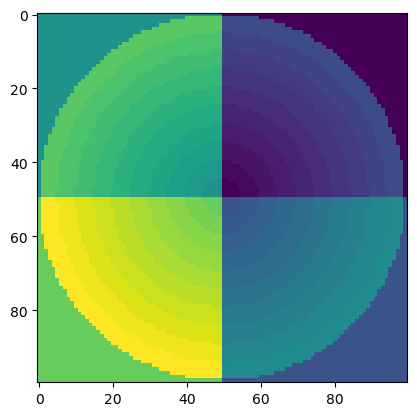

In [16]:
output_size=100
image = np.ones([output_size,output_size])

image = image.astype(np.float32)

# Create normalized square grid: x, y ∈ [-1, 1]
lin = np.linspace(-1, 1, output_size)
xv, yv = np.meshgrid(lin, lin)

# Map square to disk using a conformal mapping (polar-style)
r_norm = np.sqrt(xv**2 + yv**2)
theta = np.arctan2(yv, xv)

for i in range(10):
    image[r_norm>i/10] = i/10
image[r_norm>1] = 0
image[theta>0] = image[theta>0] +1

image[abs(theta)>np.pi/2] = image[abs(theta)>np.pi/2] +2


plt.imshow(image)

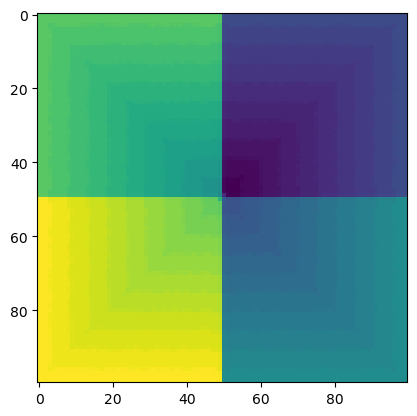

In [27]:
square_image = disk_to_square(image, output_size/2-0.5, output_size/2-0.5, output_size/2*0.95, output_size=100)
plt.imshow(square_image)

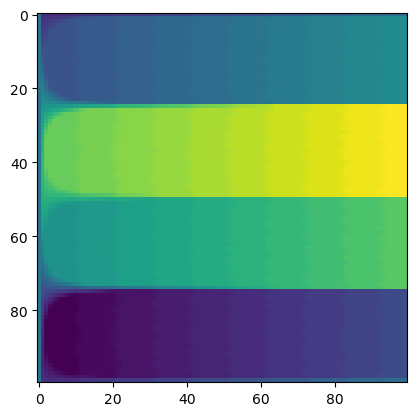

In [25]:
square_image = disk_to_fan(image, output_size/2-0.5, output_size/2-0.5, output_size/2*0.95, output_size=100)
plt.imshow(square_image)